## Step-2

### Setup

### Model-A (Non-stationary)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor

In [7]:
data = yf.download('^GSPC', start='2020-01-01', end='2025-12-31')['Close']
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data = data.rename(columns={'^GSPC': 'S&P500'})
data.head()

/tmp/ipython-input-443/502265029.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start='2020-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,S&P500
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


In [79]:
# Feature engineering
n_lags = 5
for i in range(1, n_lags + 1):
    data[f'lag_{i}'] = data['S&P500'].shift(i)

data.dropna(inplace=True)

# Split data into train and test sets (80-20 split)
X = data[[f'lag_{i}' for i in range(1, n_lags + 1)]]
y = data['S&P500']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling the features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [97]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_scaled, y_train_scaled)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=500,
             random_state=42)

In [98]:
y_pred_scaled = mlp.predict(X_test_scaled)

# Inverse-transform predictions back to their original price scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [99]:
print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 65.86
Root Mean Squared Error (RMSE): 83.78


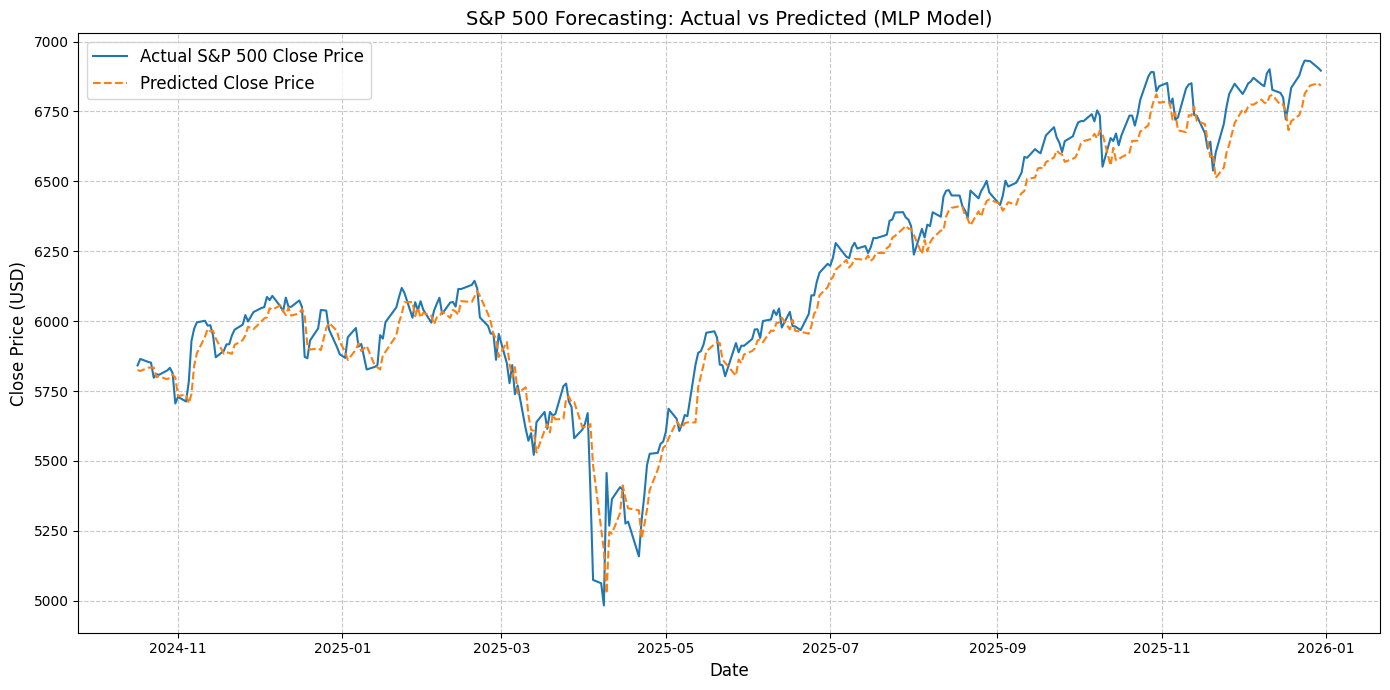

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Close Price', color='#1f77b4')
plt.plot(y_test.index, y_pred, label='Predicted Close Price', color='#ff7f0e', linestyle='--')

plt.title('S&P 500 Forecasting: Actual vs Predicted (MLP Model)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Model B (Stationary, Zero-memory)

In [3]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
data_b = yf.download('^GSPC', start='2020-01-01', end='2025-12-31')[['Close']]
if isinstance(data_b.columns, pd.MultiIndex):
    data_b.columns = data_b.columns.get_level_values(0)

/tmp/ipython-input-443/1841958089.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_b = yf.download('^GSPC', start='2020-01-01', end='2025-12-31')[['Close']]
[*********************100%***********************]  1 of 1 completed


TypeError: 'MultiIndex' object is not callable

In [ ]:

# Handle potential MultiIndex columns in newer versions of yfinance


# Transform into a stationary series using log returns 
data_b['Returns'] = np.log(data_b['Close'] / data_b['Close'].shift(1))
data_b.dropna(inplace=True) # Drop the initial NaN created by shifting

# Run the Augmented Dickey-Fuller (ADF) test
adf_stat, p_value, _, _, _, _ = adfuller(data_b['Returns'])
print("--- ADF Test on S&P 500 Log Returns ---")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Conclusion: The transformed series is strictly stationary (p-value < 0.05).\n")
else:
    print("Conclusion: The series is NOT stationary.\n")

# --- 2. Feature Engineering (Past Information) ---
n_lags = 5
for i in range(1, n_lags + 1):
    data_b[f'lag_{i}'] = data_b['Returns'].shift(i)

# Drop rows with NaN values resulting from the lag creation
data_b.dropna(inplace=True)

# Define X (features) and y (target) using the stationary returns
X_b = data_b[[f'lag_{i}' for i in range(1, n_lags + 1)]]
y_b = data_b['Returns']

# --- 3. Data Preprocessing ---
# Split the dataset chronologically (80% train, 20% test) matching Model A
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, shuffle=False)

# Scale features (Fit ONLY on training data, transform both)
scaler_X_b = StandardScaler()
X_train_scaled_b = scaler_X_b.fit_transform(X_train_b)
X_test_scaled_b = scaler_X_b.transform(X_test_b)

# Scale target (Fit ONLY on training data)
scaler_y_b = StandardScaler()
y_train_scaled_b = scaler_y_b.fit_transform(y_train_b.values.reshape(-1, 1)).ravel()

# --- 4. Model Building and Training ---
# Initialize MLPRegressor with the exact same hyperparameters used in Model A
mlp_b = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# Train the model to predict the current return using lagged returns
mlp_b.fit(X_train_scaled_b, y_train_scaled_b)

# --- 5. Evaluation and Visualization ---
# Predict the test set values
y_pred_scaled_b = mlp_b.predict(X_test_scaled_b)

# Inverse transform predictions back to the actual return scale
y_pred_returns = scaler_y_b.inverse_transform(y_pred_scaled_b.reshape(-1, 1)).ravel()

# Evaluate MAE and RMSE on the stationary predictions
mae_b = mean_absolute_error(y_test_b, y_pred_returns)
rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_returns))

print("--- Model B Evaluation (Stationary Returns) ---")
print(f"Mean Absolute Error (MAE): {mae_b:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse_b:.6f}\n")



/tmp/ipython-input-443/1463105515.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_b = yf.download('^GSPC', start='2020-01-01', end='2025-12-31')[['Close']]
[*********************100%***********************]  1 of 1 completed

--- ADF Test on S&P 500 Log Returns ---
ADF Statistic: -12.0155
p-value: 0.0000
Conclusion: The transformed series is strictly stationary (p-value < 0.05).

--- Model B Evaluation (Stationary Returns) ---
Mean Absolute Error (MAE): 0.006943
Root Mean Squared Error (RMSE): 0.011009



In [ ]:
# Plot 1: Actual vs. Predicted Stationary Returns
plt.figure(figsize=(14, 7))
plt.plot(y_test_b.index, y_test_b.values, label='Actual Log Returns', color='#1f77b4')
plt.plot(y_test_b.index, y_pred_returns, label='Predicted Log Returns', color='#ff7f0e', linestyle='--')
plt.title('Model B: Actual vs Predicted S&P 500 Log Returns', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Returns', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Optional: Cumulative Sum/Inverse-Transform back to Price Levels ---
# To compare the visual shape against Model A, reconstruct 1-step-ahead predicted prices.
# Formula: P_t = P_{t-1} * exp(R_t) using the actual previous day's closing price
test_prev_prices = data_b['Close'].shift(1).loc[y_test_b.index]
predicted_prices_b = test_prev_prices * np.exp(y_pred_returns)
actual_prices_b = data_b['Close'].loc[y_test_b.index]

# Plot 2: Reconstructed Price Levels vs Actual S&P 500 Prices
plt.figure(figsize=(14, 7))
plt.plot(actual_prices_b.index, actual_prices_b.values, label='Actual Close Price', color='#1f77b4')
plt.plot(actual_prices_b.index, predicted_prices_b, label='Predicted Close Price (via Model B Returns)', color='#2ca02c', linestyle='-.')
plt.title('Model B Reconstructed Prices: 1-Step-Ahead Forecasts vs Actual Prices', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
